# 1. Import Importance library

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from scipy.stats.mstats import winsorize

# Oversampling
from imblearn.over_sampling import SMOTE

# Linear Model
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# Support Vector Machine
from sklearn.svm import SVC

# Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import RandomForestClassifier

# Boosting
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier

# Naive Bayes
from sklearn.naive_bayes import GaussianNB

# Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier

# External Gradient Boosting
from lightgbm import LGBMClassifier

# Neural Network
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

# 2. Load the dataset

In [25]:
df= pd.read_csv('students_dropout_academic_success.csv')
df.head(5)

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [26]:
df.shape

(4424, 37)

We have 4424 data and 37 variablle

# 3. Data Summary

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [28]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital Status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


In [29]:
df.keys()

Index(['Marital Status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd s

# 4. Data Cleaning

In [30]:
print(df['target'].unique())

['Dropout' 'Graduate' 'Enrolled']


In [31]:
# Check Missing Values
df.isna().sum() / len(df) * 100

Marital Status                                    0.0
Application mode                                  0.0
Application order                                 0.0
Course                                            0.0
Daytime/evening attendance                        0.0
Previous qualification                            0.0
Previous qualification (grade)                    0.0
Nacionality                                       0.0
Mother's qualification                            0.0
Father's qualification                            0.0
Mother's occupation                               0.0
Father's occupation                               0.0
Admission grade                                   0.0
Displaced                                         0.0
Educational special needs                         0.0
Debtor                                            0.0
Tuition fees up to date                           0.0
Gender                                            0.0
Scholarship holder          

There's no missing value in this dataset

In [32]:
# Check duplicate data
df.duplicated().sum()

np.int64(0)

There's no duplicate value in this dataset

# 5. Data Visualisation

In [33]:
num_cols = df.select_dtypes(include = ['int64','float64']).columns
cat_cols = df.select_dtypes(exclude = ['int64','float64']).columns

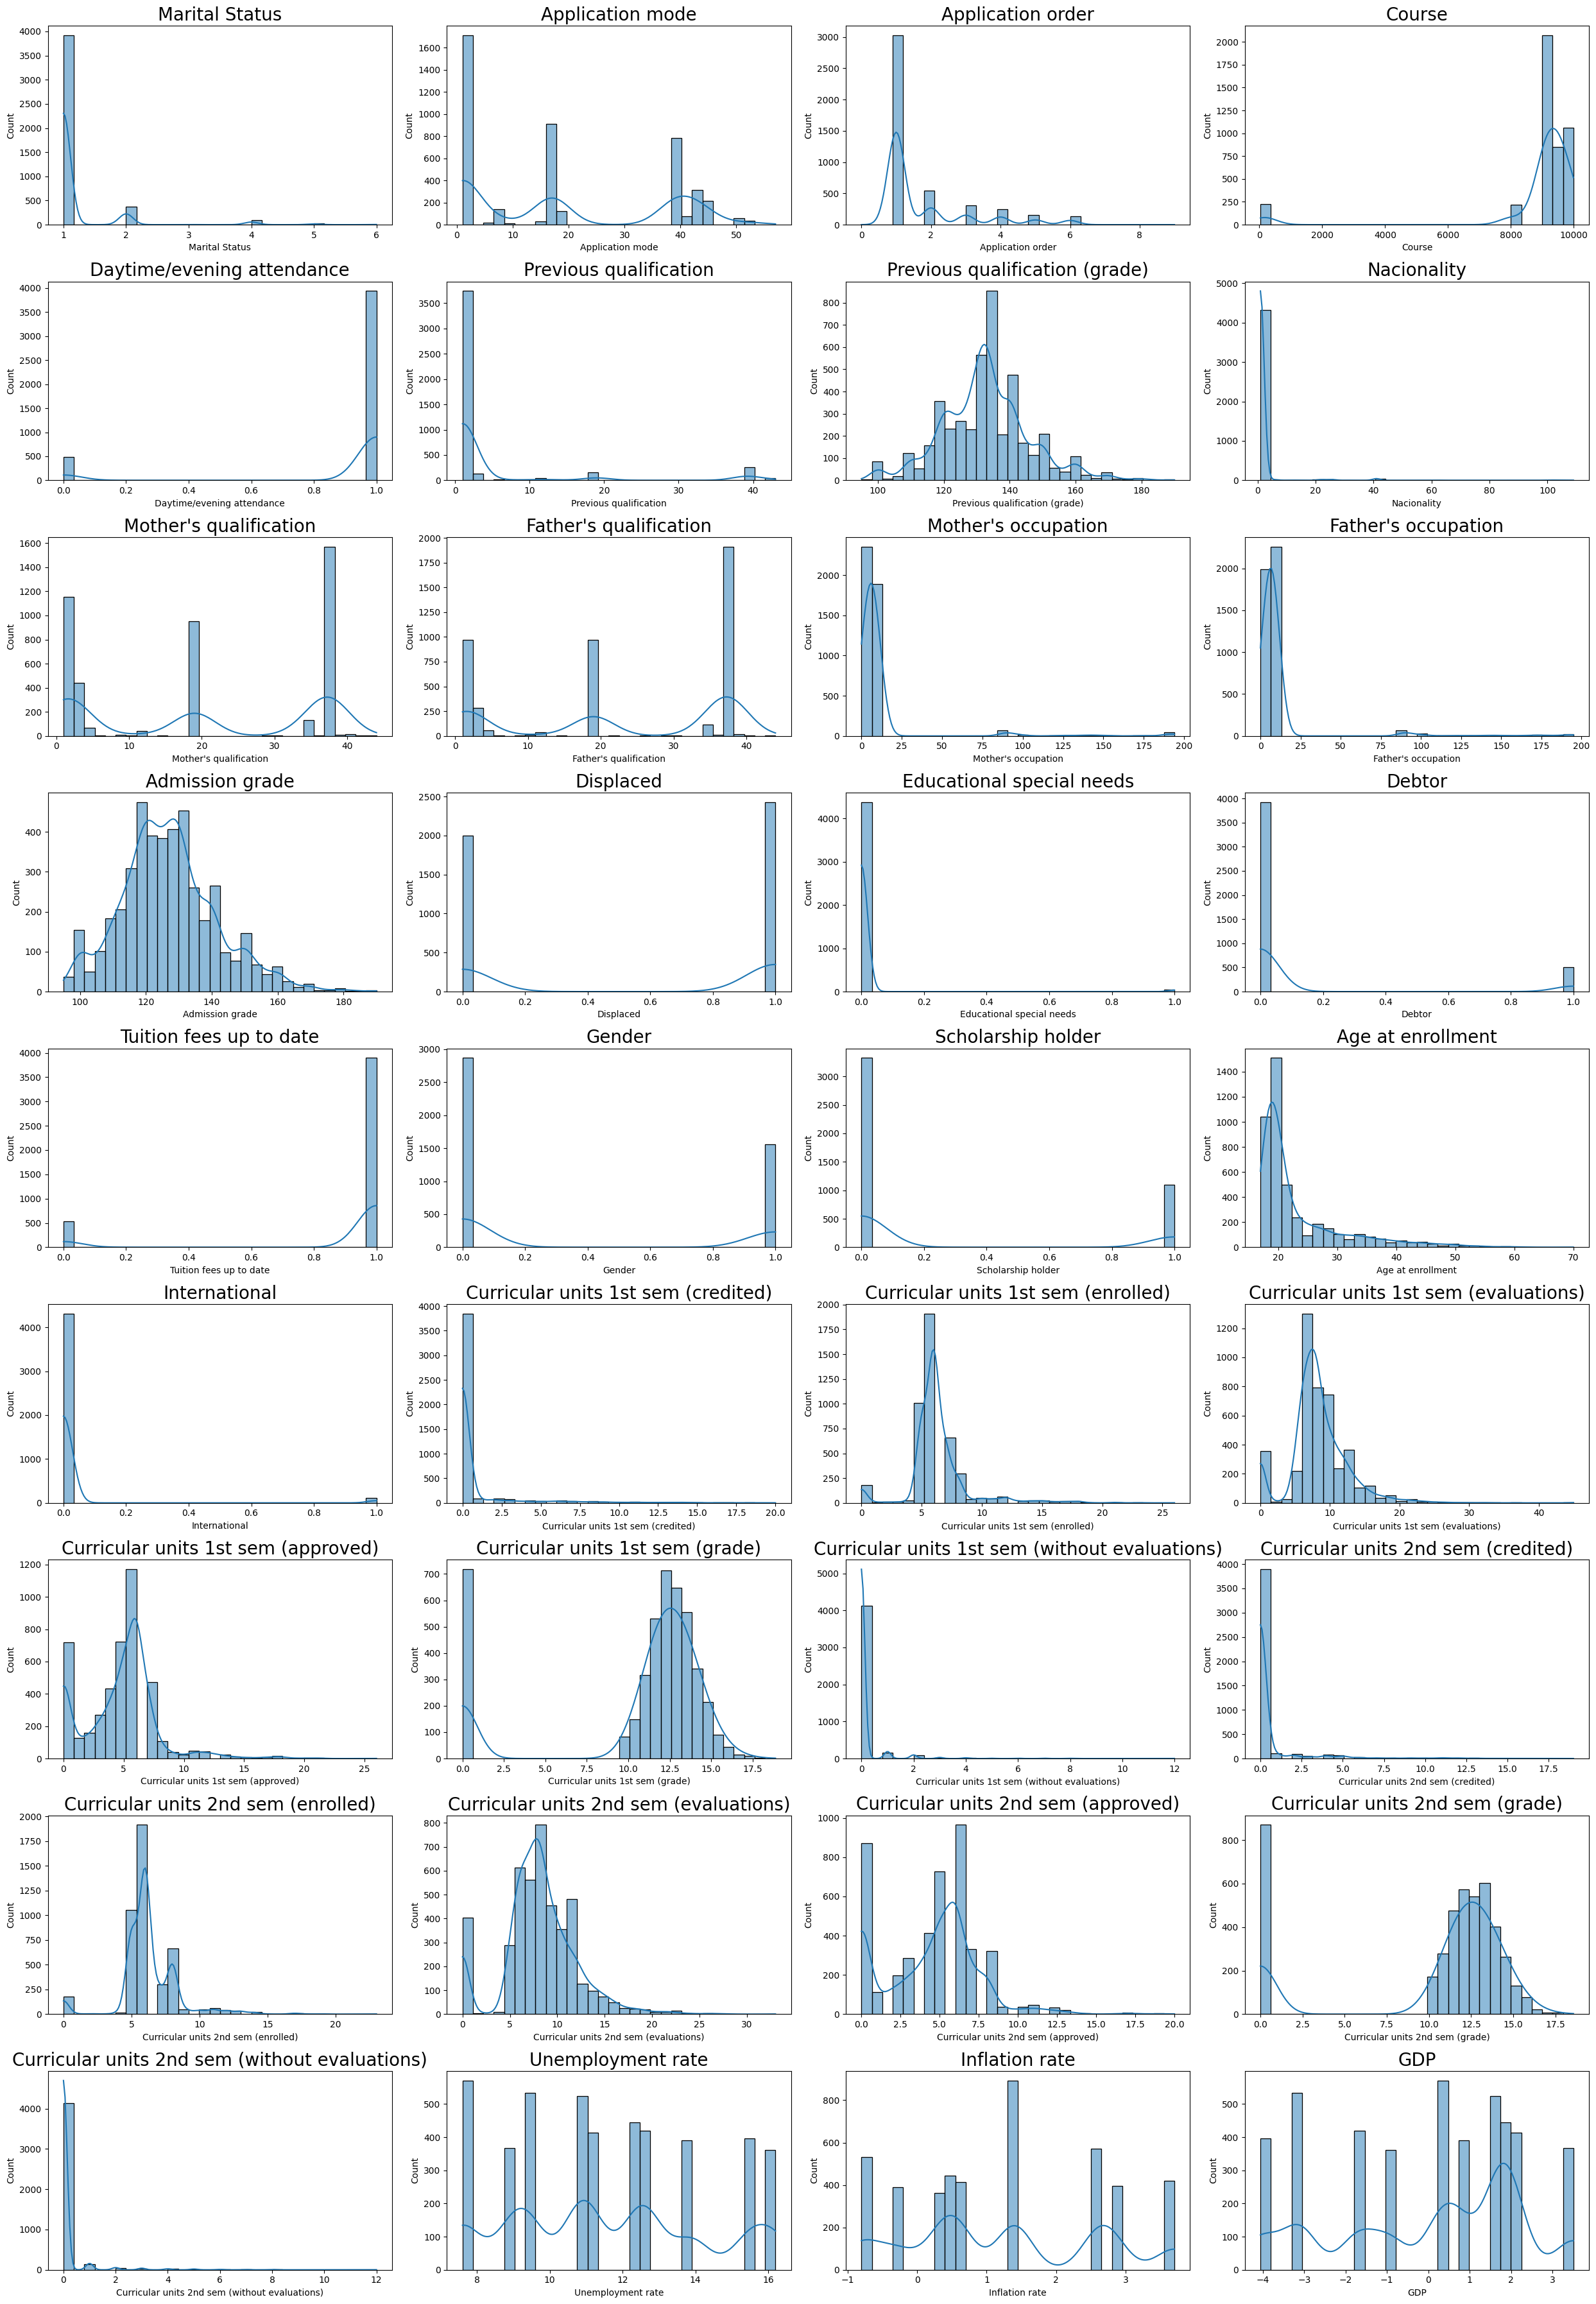

In [34]:
num_rows = (len(num_cols) + 1) // 2

f, ax = plt.subplots(9,4, figsize=(25,2 * num_rows))
ax = ax.flatten()

for index, cols in enumerate(num_cols):
    sns.histplot(data = df, x= cols, ax = ax[index],kde=True, bins=30)
    ax[index].set_title(cols, size = 20)
    
plt.tight_layout()
plt.show()

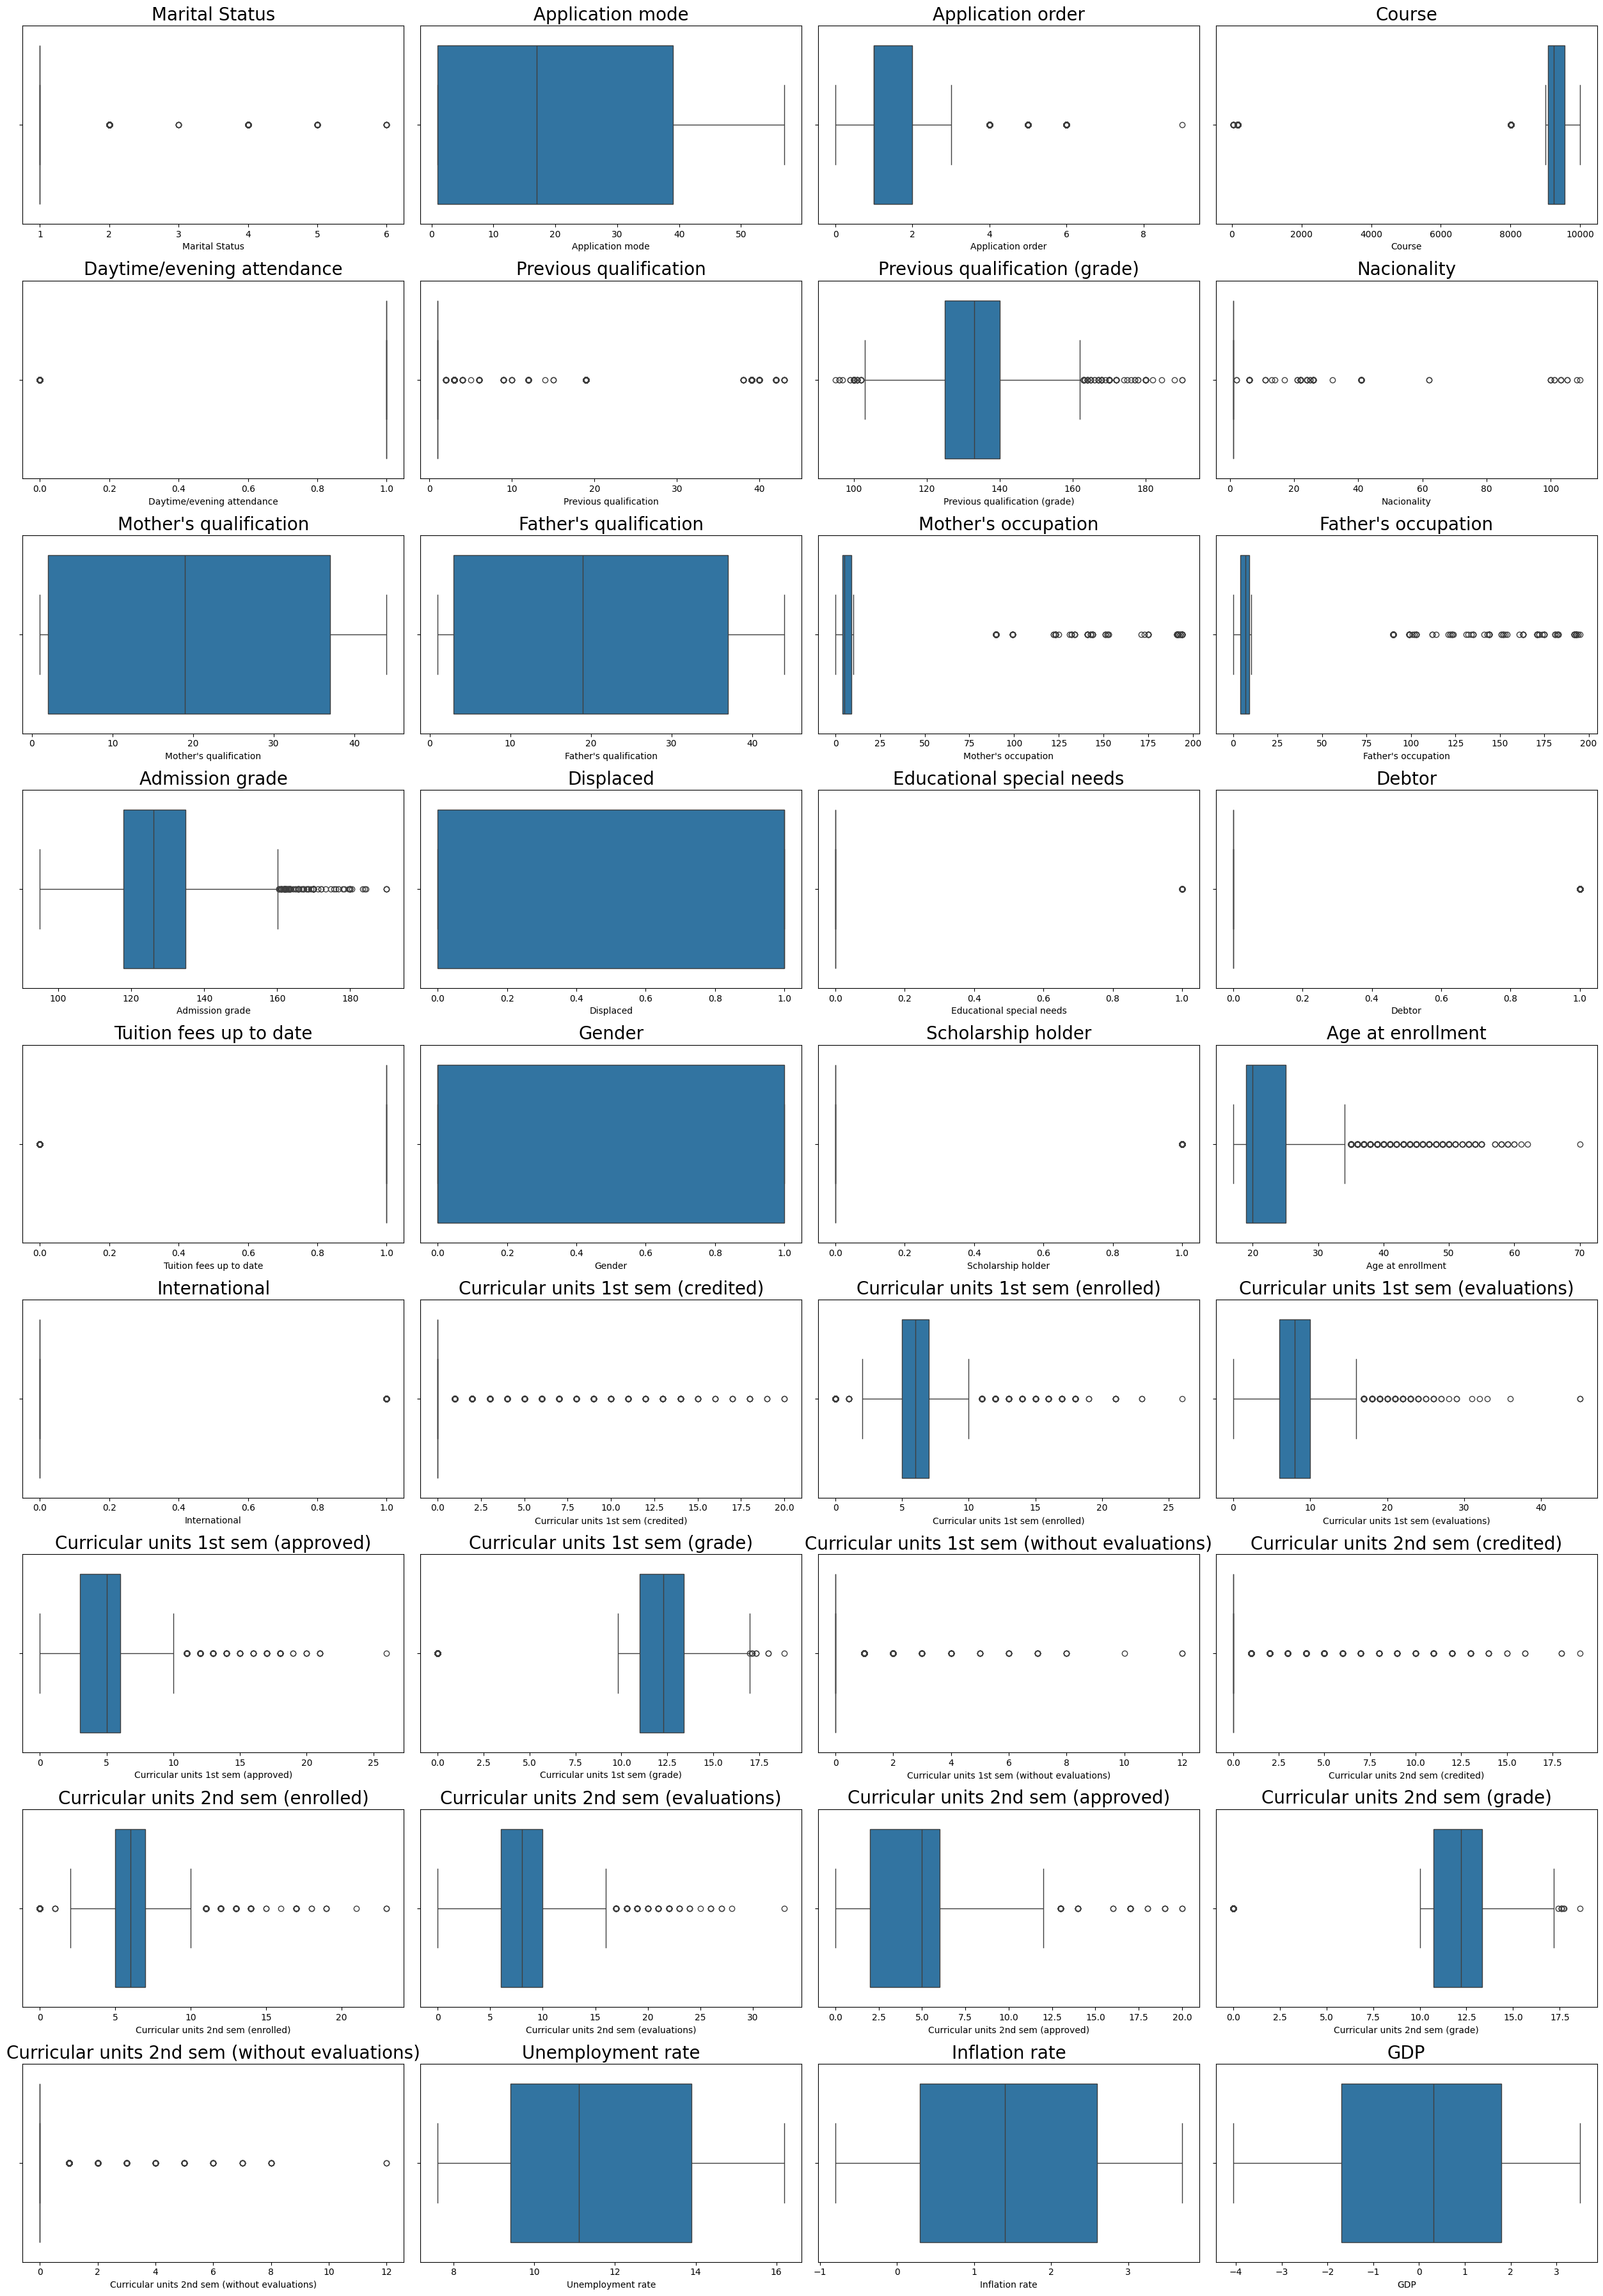

In [35]:
num_rows = (len(num_cols) + 1) // 2

f, ax = plt.subplots(9,4, figsize=(25,2 * num_rows))
ax = ax.flatten()

for index, cols in enumerate(num_cols):
    sns.boxplot(df, x= cols , ax= ax[index])
    ax[index].set_title(cols, size=20)
    
plt.tight_layout()
plt.show()

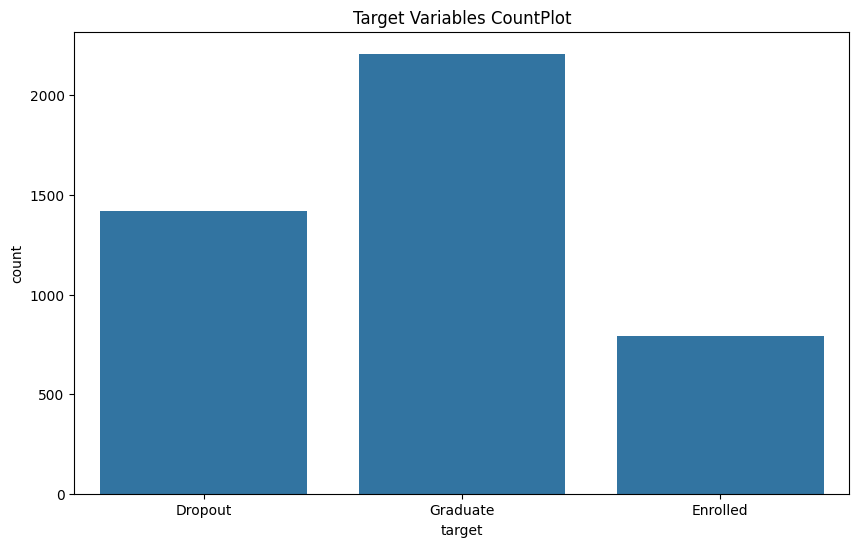

In [36]:
plt.figure(figsize=(10, 6))
sns.countplot(df, x = 'target')
plt.title('Target Variables CountPlot')
plt.show()

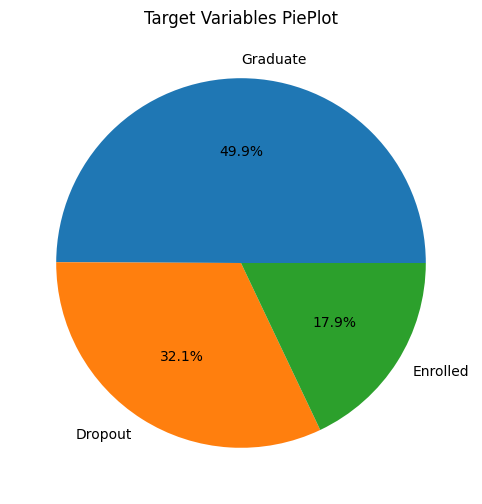

In [37]:
labels = ['Graduate','Dropout', 'Enrolled']

plt.figure(figsize=(10, 6))
plt.pie(df['target'].value_counts() , labels = labels, autopct='%.1f%%' )
plt.title('Target Variables PiePlot')
plt.show()

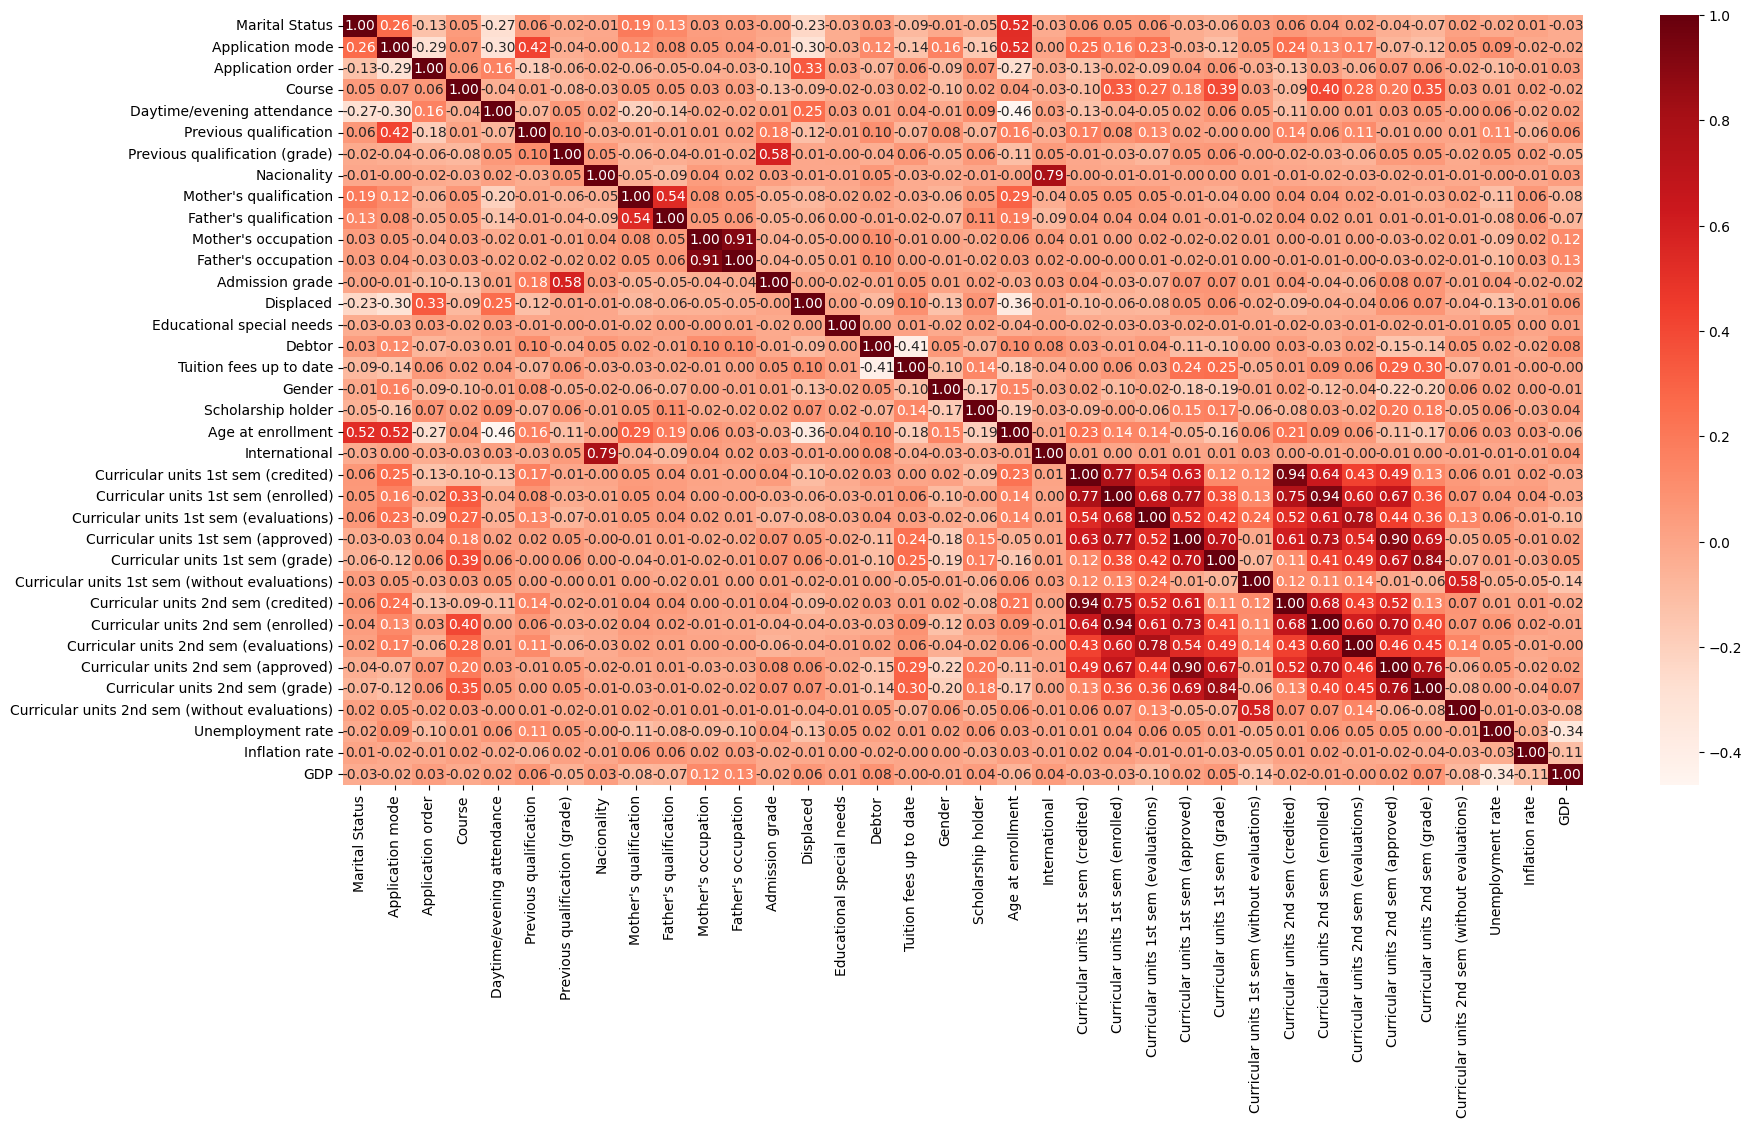

In [38]:
plt.figure(figsize=(20, 10))
sns.heatmap(df[num_cols].corr(),annot=True, cmap='Reds',fmt= '.2f')
plt.show()

# 6. Feature Engineering

## Outlier Handling

In [39]:
from scipy.stats.mstats import winsorize

df_transformed = df.copy()

# --- Log Transform (kolom skewed dan selalu positif) ---
log_transform_cols = [
    'Application order',
    'Age at enrollment',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 2nd sem (enrolled)'
]

for col in log_transform_cols:
    df_transformed[col] = np.log1p(df_transformed[col])  # log(1+x)

# --- Winsorize (batasi outlier ekstrem) ---
winsorize_cols = [
    'Admission grade',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)',
    'Mother\'s occupation',
    'Father\'s occupation'
]

for col in winsorize_cols:
    df_transformed[col] = winsorize(df_transformed[col], limits=[0.01, 0.01])

# --- Cek hasil transformasi ---
df_transformed[log_transform_cols + winsorize_cols].describe()


,Application order,Age at enrollment,Curricular units 1st sem (evaluations),Curricular units 2nd sem (evaluations),Curricular units 1st sem (enrolled),Curricular units 2nd sem (enrolled),Admission grade,Curricular units 1st sem (grade),Curricular units 2nd sem (grade),Mother's occupation,Father's occupation
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,0.920511,3.151732,2.075025,2.041237,1.909321,1.910361,126.927080,10.634238,10.224007,10.950497,10.888788
std,0.375216,0.256310,0.676115,0.702082,0.452198,0.441691,14.188349,4.835557,5.203243,26.346764,24.278014
min,0.000000,2.890372,0.000000,0.000000,0.000000,0.000000,99.000000,0.000000,0.000000,0.000000,0.000000
25%,0.693147,2.995732,1.945910,1.945910,1.791759,1.791759,117.900000,11.000000,10.750000,4.000000,4.000000
50%,0.693147,3.044522,2.197225,2.197225,1.945910,1.945910,126.100000,12.285714,12.200000,5.000000,7.000000
75%,1.098612,3.258097,2.397895,2.397895,2.079442,2.079442,134.800000,13.400000,13.333333,9.000000,9.000000
max,2.302585,4.262680,3.828641,3.526361,3.295837,3.178054,166.900000,16.000000,16.000000,191.000000,171.000000


Dalam preprocessing data, saya menggunakan log transform dan winsorize untuk menangani distribusi yang tidak normal dan outlier.

Log transform digunakan pada fitur-fitur yang memiliki sebaran skewed (miring ke kanan) dan hanya berisi nilai positif. Tujuannya untuk menormalkan distribusi, mengurangi pengaruh nilai ekstrem, dan membantu model yang sensitif terhadap skala.

Winsorize digunakan untuk membatasi outlier ekstrem dengan menggantinya pada batas persentil tertentu (misalnya 1% dan 99%), agar data tidak terlalu terpengaruh oleh nilai yang tidak representatif tanpa harus menghapusnya.

Kedua teknik ini dipilih karena lebih efektif dibanding Z-score atau IQR dalam kasus data yang tidak normal dan mengandung banyak outlier, seperti pada dataset ini yang memiliki target multiclass.

## Encoding

In [40]:
from sklearn.preprocessing import OneHotEncoder

onehot_cols = [
    'Marital Status', 'Application mode', 'Course', 'Daytime/evening attendance',
    'Nacionality', "Mother's occupation", "Father's occupation",
    'Displaced', 'Educational special needs', 'Debtor',
    'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International',"Mother's qualification",
    "Father's qualification",'Previous qualification'
]

df_transformed = pd.get_dummies(df_transformed, columns=onehot_cols, drop_first=True)

In [41]:
df_transformed.head(5).T

,0,1,2,3,4
Application order,1.791759,0.693147,1.791759,1.098612,0.693147
Previous qualification (grade),122.0,160.0,122.0,122.0,100.0
Admission grade,127.3,142.5,124.8,119.6,141.5
Age at enrollment,3.044522,2.995732,2.995732,3.044522,3.828641
Curricular units 1st sem (credited),0,0,0,0,0
...,...,...,...,...,...
Previous qualification_38,False,False,False,False,False
Previous qualification_39,False,False,False,False,False
Previous qualification_40,False,False,False,False,False
Previous qualification_42,False,False,False,False,False


In [42]:
df_transformed.shape

(4424, 226)

One-Hot Encoding digunakan untuk mengubah fitur kategorik nominal menjadi representasi numerik yang dapat dibaca oleh model machine learning. Teknik ini mencegah model mengasumsikan adanya urutan atau hubungan matematis antar kategori, karena setiap kategori diubah menjadi kolom biner (0 atau 1).

## Scaling

In [43]:
numeric_cols = df_transformed.select_dtypes(include='number').columns.tolist()

numeric_cols = [col for col in numeric_cols if df_transformed[col].nunique() > 2]

# Inisialisasi dan scaling
scaler = StandardScaler()
df_transformed[numeric_cols] = scaler.fit_transform(df_transformed[numeric_cols])

# Cek hasil
df_transformed[numeric_cols].describe()

,Application order,Previous qualification (grade),Admission grade,Age at enrollment,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4.424000e+03,4.424000e+03,4.424000e+03,4.424000e+03,4.424000e+03,4.424000e+03,4.424000e+03,4.424000e+03,4.424000e+03,4.424000e+03,4.424000e+03,4.424000e+03,4.424000e+03,4.424000e+03,4.424000e+03,4.424000e+03,4.424000e+03,4.424000e+03,4.424000e+03
mean,-1.188521e-16,-3.589654e-16,-7.195369e-16,1.856662e-15,3.212219e-17,5.187733e-16,-9.476045e-17,3.051608e-17,-1.509743e-16,9.636656e-18,-3.212219e-18,5.067275e-16,-1.509743e-16,-1.509743e-16,1.220643e-16,3.212219e-18,-5.460771e-17,1.445498e-16,2.569775e-17
std,1.000113e+00,1.000113e+00,1.000113e+00,1.000113e+00,1.000113e+00,1.000113e+00,1.000113e+00,1.000113e+00,1.000113e+00,1.000113e+00,1.000113e+00,1.000113e+00,1.000113e+00,1.000113e+00,1.000113e+00,1.000113e+00,1.000113e+00,1.000113e+00,1.000113e+00
min,-2.453564e+00,-2.852337e+00,-1.968533e+00,-1.019819e+00,-3.008131e-01,-4.222784e+00,-3.069388e+00,-1.521257e+00,-2.199424e+00,-1.992730e-01,-2.824423e-01,-4.325593e+00,-2.907733e+00,-1.471527e+00,-1.965152e+00,-1.994410e-01,-1.489043e+00,-1.466871e+00,-1.789667e+00
25%,-6.060248e-01,-5.773417e-01,-6.363038e-01,-6.087061e-01,-3.008131e-01,-2.600061e-01,-1.909879e-01,-5.516038e-01,7.564871e-02,-1.992730e-01,-2.824423e-01,-2.685470e-01,-1.357924e-01,-8.080500e-01,1.011008e-01,-1.994410e-01,-8.132529e-01,-6.712423e-01,-7.498721e-01
50%,-6.060248e-01,3.690696e-02,-5.829946e-02,-4.183285e-01,-3.008131e-01,8.092410e-02,1.807577e-01,9.483201e-02,3.415663e-01,-1.992730e-01,-2.824423e-01,8.049339e-02,2.222038e-01,1.871653e-01,3.798047e-01,-1.994410e-01,-1.750068e-01,1.243865e-01,1.401217e-01
75%,4.747164e-01,5.601559e-01,5.549490e-01,4.150305e-01,-3.008131e-01,3.762512e-01,4.775908e-01,4.180499e-01,5.720282e-01,-1.992730e-01,-2.824423e-01,3.828459e-01,5.080584e-01,5.189037e-01,5.976422e-01,-1.994410e-01,8.762221e-01,9.923451e-01,7.877904e-01
max,3.683829e+00,4.351815e+00,2.817625e+00,4.334881e+00,8.172902e+00,3.066514e+00,2.593958e+00,6.882407e+00,1.109773e+00,1.717184e+01,9.622009e+00,2.870413e+00,2.115552e+00,5.163242e+00,1.110201e+00,1.572225e+01,1.739731e+00,1.787974e+00,1.545607e+00


Saya menggunakan StandardScaler untuk menormalkan fitur numerik agar memiliki mean 0 dan standar deviasi 1. Ini penting agar algoritma seperti KNN, SVM, dan Logistic Regression bisa bekerja optimal, karena mereka sensitif terhadap skala antar fitur.

In [44]:
df_transformed.head()

,Application order,Previous qualification (grade),Admission grade,Age at enrollment,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),...,Previous qualification_10,Previous qualification_12,Previous qualification_14,Previous qualification_15,Previous qualification_19,Previous qualification_38,Previous qualification_39,Previous qualification_40,Previous qualification_42,Previous qualification_43
0,2.322256,-0.804841,0.026287,-0.418328,-0.300813,-4.222784,-3.069388,-1.521257,-2.199424,-0.199273,...,False,False,False,False,False,False,False,False,False,False
1,-0.606025,2.076819,1.097709,-0.608706,-0.300813,0.080924,-0.190988,0.418050,0.696123,-0.199273,...,False,False,False,False,False,False,False,False,False,False
2,2.322256,-0.804841,-0.149934,-0.608706,-0.300813,0.080924,-3.069388,-1.521257,-2.199424,-0.199273,...,False,False,False,False,False,False,False,False,False,False
3,0.474716,-0.804841,-0.516474,-0.418328,-0.300813,0.080924,0.180758,0.418050,0.577937,-0.199273,...,False,False,False,False,False,False,False,False,False,False
4,-0.606025,-2.473171,1.027221,2.641277,-0.300813,0.080924,0.336607,0.094832,0.351415,-0.199273,...,False,False,False,False,False,False,False,False,False,False


# 7. Mechine Learning Model 

## Feature Selection

In [45]:
y = df_transformed['target']
X = df_transformed.drop('target', axis=1)

## Data Splitting

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 100)

print(f'Total: {len(X)}')
print(f'Total train sample: {len(X_train)}')
print(f'Total test sample: {len(X_test)}')

Total: 4424
Total train sample: 3539
Total test sample: 885


## Oversampling

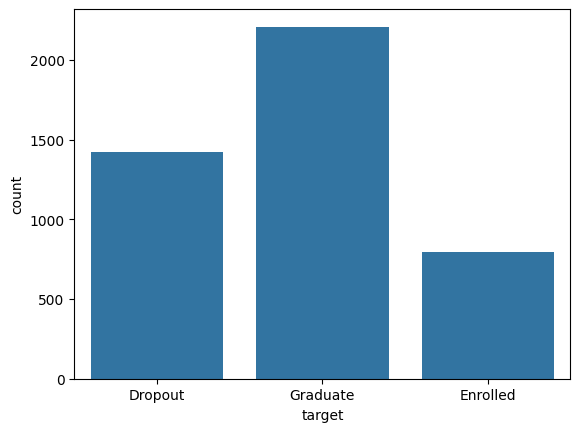

In [47]:
sns.countplot(data=df, x= 'target')
plt.show()

In [48]:
df['target'].value_counts(normalize=True) * 100

target
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: proportion, dtype: float64

imblance data, so kita perlu oversampling menggunakan SMOTE

SMOTE digunakan karena data target tidak seimbang — mayoritas kelas adalah Graduate (49.9%), sedangkan Enrolled hanya 17.9%. Untuk mencegah model bias terhadap kelas mayoritas, SMOTE menambahkan data sintetis ke kelas minoritas agar model bisa belajar secara adil dari semua kelas.

In [49]:
# Oversampling menggunakan SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(y_train_resampled.value_counts())

target
Dropout     1752
Graduate    1752
Enrolled    1752
Name: count, dtype: int64


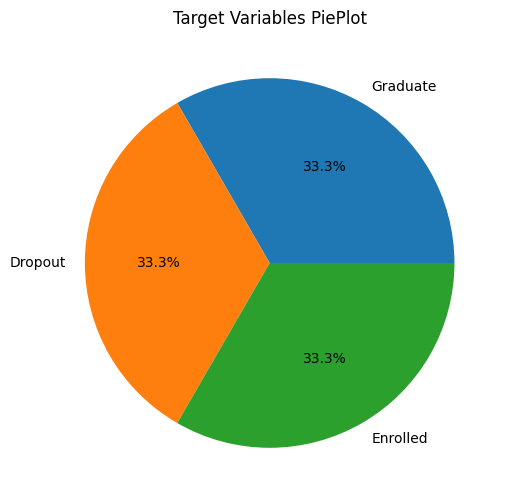

In [50]:
labels = ['Graduate','Dropout', 'Enrolled']

plt.figure(figsize=(10, 6))
plt.pie(y_train_resampled.value_counts() , labels = labels, autopct='%.1f%%' )
plt.title('Target Variables PiePlot')
plt.show()

## Model Training

In [51]:
# 1. Logistic Regression
model_lr = LogisticRegression(random_state=100)
model_lr.fit(X_train_resampled, y_train_resampled)
y_pred_lr = model_lr.predict(X_test)

C:\Users\Mumtaz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [52]:
# 2. SGD Classifier
model_sgd = SGDClassifier(random_state=100)
model_sgd.fit(X_train_resampled, y_train_resampled)
y_pred_sgd = model_sgd.predict(X_test)

In [53]:
# 3. Linear Discriminant Analysis
model_lda = LinearDiscriminantAnalysis()
model_lda.fit(X_train_resampled, y_train_resampled)
y_pred_lda = model_lda.predict(X_test)

In [54]:
# 4. Quadratic Discriminant Analysis
model_qda = QuadraticDiscriminantAnalysis()
model_qda.fit(X_train_resampled, y_train_resampled)
y_pred_qda = model_qda.predict(X_test)

C:\Users\Mumtaz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
C:\Users\Mumtaz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
C:\Users\Mumtaz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 2 is not full rank. Increasing the value of parameter `reg_param` might help reduci

In [55]:
# 5. Support Vector Machine
model_svc = SVC(random_state=100)
model_svc.fit(X_train_resampled, y_train_resampled)
y_pred_svc = model_svc.predict(X_test)

In [56]:
# 6. Decision Tree
model_dt = DecisionTreeClassifier(random_state=100)
model_dt.fit(X_train_resampled, y_train_resampled)
y_pred_dt = model_dt.predict(X_test)


In [57]:
# 7. Extra Trees
model_et = ExtraTreesClassifier(random_state=100)
model_et.fit(X_train_resampled, y_train_resampled)
y_pred_et = model_et.predict(X_test)

In [58]:
# 8. Random Forest
model_rf = RandomForestClassifier(random_state=100)
model_rf.fit(X_train_resampled, y_train_resampled)
y_pred_rf = model_rf.predict(X_test)

In [59]:
# 9. Gradient Boosting
model_gb = GradientBoostingClassifier(random_state=100)
model_gb.fit(X_train_resampled, y_train_resampled)
y_pred_gb = model_gb.predict(X_test)

In [60]:
# 10. Hist Gradient Boosting
model_hgb = HistGradientBoostingClassifier(random_state=100)
model_hgb.fit(X_train_resampled, y_train_resampled)
y_pred_hgb = model_hgb.predict(X_test)

In [61]:
# 11. AdaBoost
model_ada = AdaBoostClassifier(random_state=100)
model_ada.fit(X_train_resampled, y_train_resampled)
y_pred_ada = model_ada.predict(X_test)

In [62]:
# 12. Gaussian Naive Bayes
model_nb = GaussianNB()
model_nb.fit(X_train_resampled, y_train_resampled)
y_pred_nb = model_nb.predict(X_test)

In [63]:
# 13. K-Nearest Neighbors
model_knn = KNeighborsClassifier()
model_knn.fit(X_train_resampled, y_train_resampled)
y_pred_knn = model_knn.predict(X_test)

In [64]:
# 14. LightGBM
model_lgbm = LGBMClassifier(random_state=42)
model_lgbm.fit(X_train_resampled, y_train_resampled)
y_pred_lgbm = model_lgbm.predict(X_test)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001522 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4219
[LightGBM] [Info] Number of data points in the train set: 5256, number of used features: 114
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


In [65]:
# 15. MLP Classifier
model_mlp = MLPClassifier(random_state=42)
model_mlp.fit(X_train_resampled, y_train_resampled)
y_pred_mlp = model_mlp.predict(X_test)

C:\Users\Mumtaz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


# 8. Model Evaluation

## Before Hypertunning and choose best model

In [66]:
# ROC AUC Comparison
plt.figure(figsize=(12, 8))

models = {
    "Logistic Regression": model_lr,
    "SGD": model_sgd,
    "LDA": model_lda,
    "QDA": model_qda,
    "SVC": model_svc,
    "Decision Tree": model_dt,
    "Extra Trees": model_et,
    "Random Forest": model_rf,
    "GB": model_gb,
    "HistGB": model_hgb,
    "AdaBoost": model_ada,
    "Gaussian NB": model_nb,
    "KNN": model_knn,
    "LightGBM": model_lgbm,
    "MLP": model_mlp
}

<Figure size 1200x800 with 0 Axes>

In [69]:
# Simpan confusion matrices dan metrics
all_cms = []
metrics = {
    "Model": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1 Score": [],
    "Correct": [],
    "Total": [],
    "Misclassified": []
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    all_cms.append(cm)

    correct = cm.trace()  # jumlah nilai diagonal (prediksi benar)
    total = cm.sum()
    misclassified = total - correct

    metrics["Model"].append(name)
    metrics["Accuracy"].append(accuracy_score(y_test, y_pred))
    metrics["Precision"].append(precision_score(y_test, y_pred, average='weighted', zero_division=0))
    metrics["Recall"].append(recall_score(y_test, y_pred, average='weighted'))
    metrics["F1 Score"].append(f1_score(y_test, y_pred, average='weighted'))
    metrics["Correct"].append(correct)
    metrics["Total"].append(total)
    metrics["Misclassified"].append(misclassified)

# Buat DataFrame
df_metrics = pd.DataFrame(metrics)

# Urutkan dari model terbaik (akurasi tertinggi)
df_sorted = df_metrics.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

# Tambahkan kolom peringkat
df_sorted.insert(0, 'Rank', df_sorted.index + 1)

# Tampilkan tabel
display(df_sorted[["Rank", "Model", "Accuracy", "Correct", "Misclassified", "Precision", "Recall", "F1 Score"]])

,Rank,Model,Accuracy,Correct,Misclassified,Precision,Recall,F1 Score
0,1,HistGB,0.794350,703,182,0.783439,0.794350,0.786497
1,2,LightGBM,0.794350,703,182,0.784475,0.794350,0.787278
2,3,Random Forest,0.788701,698,187,0.783818,0.788701,0.783671
3,4,SVC,0.779661,690,195,0.776769,0.779661,0.775836
4,5,Logistic Regression,0.779661,690,195,0.775014,0.779661,0.776310
5,6,Extra Trees,0.775141,686,199,0.764491,0.775141,0.766961
6,7,SGD,0.775141,686,199,0.770537,0.775141,0.769049
7,8,GB,0.775141,686,199,0.779218,0.775141,0.776454
8,9,LDA,0.763842,676,209,0.755990,0.763842,0.755584
9,10,AdaBoost,0.728814,645,240,0.763110,0.728814,0.739713


Dari hasil diatas kita mau ambil 5 Model Terbaik Berdasarkan Hasil Evaluasi,


Alasan Memilih 5 Model Terbaik Berdasarkan Hasil Evaluasi

HistGradientBoosting dipilih karena model ini sangat cocok untuk data yang sudah mengalami banyak feature engineering, seperti one-hot encoding dan log transform. Selain cepat dan efisien, model ini juga mampu menangani data dalam jumlah besar serta bekerja baik pada fitur numerik dan kategorikal. Hasil akurasinya juga menjadi yang tertinggi dari seluruh model, menunjukkan kemampuannya dalam memahami pola yang kompleks dalam dataset ini.

LightGBM menjadi pilihan karena ia merupakan boosting model yang sangat efisien untuk data berdimensi tinggi—cocok dengan kondisi dataset yang sudah diperluas melalui encoding. LightGBM juga dikenal sangat baik dalam menangani data imbalance, yang relevan dengan kondisi target variabelmu. Selain itu, performanya setara dengan HistGB, menjadikannya alternatif kuat dengan kecepatan pelatihan yang tinggi.

Random Forest dipilih karena model ini stabil, tidak terlalu sensitif terhadap outlier, dan dapat memberikan hasil yang cukup baik tanpa perlu banyak tuning. Ini cocok untuk kamu yang ingin model yang kuat dan mudah diterapkan sebagai baseline, terutama setelah transformasi seperti winsorizing dan scaling.

SVC (Support Vector Classifier) menjadi kandidat karena model ini unggul dalam membentuk boundary yang jelas antara kelas, terutama jika kelas-kelas memiliki batasan yang tidak linier. Karena datamu telah diskalakan dengan StandardScaler, SVC dapat bekerja optimal. Meski butuh waktu pelatihan lebih lama, performanya menunjukkan model ini mampu beradaptasi dengan kompleksitas fitur yang dihasilkan.

Logistic Regression tetap dipertahankan karena model ini sederhana, mudah diinterpretasikan, dan menjadi acuan yang baik dalam membandingkan model lain. Dengan data yang telah distandarisasi dan ditransformasi, Logistic Regression masih mampu memberikan akurasi dan F1-score yang cukup tinggi, membuktikan bahwa bahkan model yang simpel bisa bersaing saat datanya diolah dengan baik.

## Hypertunning Using RandomSearch

Kenapa pakai RandomizedSearchCV?
Lebih cepat & efisien – tidak mencoba semua kombinasi seperti GridSearchCV.

Cocok untuk banyak parameter – bisa menjelajahi ruang parameter besar tanpa butuh waktu lama.

Bisa sampling dari distribusi – fleksibel untuk nilai continuous seperti learning rate.

Hasil cukup optimal – sering menemukan kombinasi bagus dengan lebih sedikit percobaan.

Hemat resource – cocok kalau pakai laptop atau waktu training terbatas.

In [70]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import HistGradientBoostingClassifier

print("Tuning HistGradientBoosting...")
hgb_params = {
    'max_iter': [100, 200, 300, 400],
    'learning_rate': np.linspace(0.01, 0.3, 10),
    'max_depth': [None, 5, 10, 15],
    'l2_regularization': [0, 0.1, 0.3, 0.5, 1.0]
}

rsearch_hgb = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=100),
    hgb_params,
    n_iter=30,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=100
)
rsearch_hgb.fit(X_train_resampled, y_train_resampled)
print(f"Best HistGB: {rsearch_hgb.best_params_}, F1: {rsearch_hgb.best_score_}")

Tuning HistGradientBoosting...
Best HistGB: {'max_iter': 400, 'max_depth': None, 'learning_rate': np.float64(0.20333333333333334), 'l2_regularization': 0.1}, F1: 0.8274310373417532


In [71]:
print("\nTuning LightGBM...")
lgbm_params = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': np.linspace(0.01, 0.3, 10),
    'num_leaves': [15, 31, 50, 75, 100],
    'reg_alpha': [0, 0.1, 0.3, 0.5, 1.0],
    'reg_lambda': [0, 0.1, 0.3, 0.5, 1.0]
}
rsearch_lgbm = RandomizedSearchCV(
    LGBMClassifier(random_state=100),
    lgbm_params,
    n_iter=30,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=100
)
rsearch_lgbm.fit(X_train_resampled, y_train_resampled)
print(f"Best LGBM: {rsearch_lgbm.best_params_}, F1: {rsearch_lgbm.best_score_}")


Tuning LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002511 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4219
[LightGBM] [Info] Number of data points in the train set: 5256, number of used features: 114
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

In [72]:
print("\nTuning Random Forest...")
rf_params = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 4, 6, 8],
    'min_samples_leaf': [1, 2, 3, 4]
}
rsearch_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=100),
    rf_params,
    n_iter=30,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=100
)
rsearch_rf.fit(X_train_resampled, y_train_resampled)
print(f"Best RF: {rsearch_rf.best_params_}, F1: {rsearch_rf.best_score_}")


Tuning Random Forest...
Best RF: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}, F1: 0.8489052120930051


In [73]:
print("\nTuning Support Vector Classifier...")
svc_params = {
    'C': np.logspace(-2, 2, 10),
    'gamma': ['scale', 'auto'] + list(np.logspace(-2, 1, 4)),
    'kernel': ['rbf', 'linear']
}
rsearch_svc = RandomizedSearchCV(
    SVC(random_state=100),
    svc_params,
    n_iter=20,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=100
)
rsearch_svc.fit(X_train_resampled, y_train_resampled)
print(f"Best SVC: {rsearch_svc.best_params_}, F1: {rsearch_svc.best_score_}")


Tuning Support Vector Classifier...
Best SVC: {'kernel': 'rbf', 'gamma': np.float64(0.1), 'C': np.float64(0.5994842503189409)}, F1: 0.8239766869483249


In [74]:
print("\nTuning Logistic Regression...")
lr_params = {
    'C': np.logspace(-3, 2, 10),
    'penalty': ['l2'],
    'solver': ['liblinear', 'lbfgs']
}
rsearch_lr = RandomizedSearchCV(
    LogisticRegression(random_state=100, max_iter=2000),
    lr_params,
    n_iter=15,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=100
)
rsearch_lr.fit(X_train_resampled, y_train_resampled)
print(f"Best LR: {rsearch_lr.best_params_}, F1: {rsearch_lr.best_score_}")



Tuning Logistic Regression...
Best LR: {'solver': 'liblinear', 'penalty': 'l2', 'C': np.float64(0.046415888336127795)}, F1: 0.7470242406719972


## FINAL MODEL EVALUATION AFTER TUNNING

In [98]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Gunakan estimator terbaik dari hasil RandomizedSearchCV
tuned_models = {
    "HistGradientBoosting (Tuned)": rsearch_hgb.best_estimator_,
    "LightGBM (Tuned)": rsearch_lgbm.best_estimator_,
    "Random Forest (Tuned)": rsearch_rf.best_estimator_,
    "SVC (Tuned)": rsearch_svc.best_estimator_,
    "Logistic Regression (Tuned)": rsearch_lr.best_estimator_
}

# Siapkan dictionary untuk menyimpan metrik
tuned_metrics = {
    "Model": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1 Score": []
}

# Evaluasi semua model
for name, model in tuned_models.items():
    y_pred = model.predict(X_test)

    tuned_metrics["Model"].append(name)
    tuned_metrics["Accuracy"].append(accuracy_score(y_test, y_pred))
    tuned_metrics["Precision"].append(precision_score(y_test, y_pred, average='weighted', zero_division=0))
    tuned_metrics["Recall"].append(recall_score(y_test, y_pred, average='weighted'))
    tuned_metrics["F1 Score"].append(f1_score(y_test, y_pred, average='weighted'))

# Buat DataFrame dan urutkan berdasarkan akurasi
df_tuned_metrics = pd.DataFrame(tuned_metrics)
df_tuned_sorted = df_tuned_metrics.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
df_tuned_sorted.insert(0, 'Rank', df_tuned_sorted.index + 1)

# Tampilkan hasil akhir
display(df_tuned_sorted[["Rank", "Model", "Accuracy", "Precision", "Recall", "F1 Score"]])


,Rank,Model,Accuracy,Precision,Recall,F1 Score
0,1,HistGradientBoosting (Tuned),0.955932,0.955959,0.955932,0.955537
1,2,LightGBM (Tuned),0.955932,0.955927,0.955932,0.955553
2,3,Random Forest (Tuned),0.954802,0.955424,0.954802,0.954191
3,4,SVC (Tuned),0.850847,0.848505,0.850847,0.842047
4,5,Logistic Regression (Tuned),0.794350,0.781923,0.794350,0.772743


In [99]:
tuned_models = {
    "HistGradientBoosting (Tuned)": rsearch_hgb.best_estimator_,
    "LightGBM (Tuned)": rsearch_lgbm.best_estimator_,
    "Random Forest (Tuned)": rsearch_rf.best_estimator_,
    "SVC (Tuned)": rsearch_svc.best_estimator_,
    "Logistic Regression (Tuned)": rsearch_lr.best_estimator_
}

for name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    print(f"\n{name}:\n{classification_report(y_test, y_pred)}")



HistGradientBoosting (Tuned):
              precision    recall  f1-score   support

     Dropout       0.97      0.95      0.96       264
    Enrolled       0.95      0.88      0.91       164
    Graduate       0.95      0.98      0.97       457

    accuracy                           0.96       885
   macro avg       0.96      0.94      0.95       885
weighted avg       0.96      0.96      0.96       885


LightGBM (Tuned):
              precision    recall  f1-score   support

     Dropout       0.97      0.95      0.96       264
    Enrolled       0.94      0.88      0.91       164
    Graduate       0.95      0.98      0.97       457

    accuracy                           0.96       885
   macro avg       0.96      0.94      0.95       885
weighted avg       0.96      0.96      0.96       885


Random Forest (Tuned):
              precision    recall  f1-score   support

     Dropout       0.97      0.96      0.97       264
    Enrolled       0.97      0.85      0.91       164
 

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001040 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1281
[LightGBM] [Info] Number of data points in the train set: 3539, number of used features: 104
[LightGBM] [Info] Start training from score -1.136331
[LightGBM] [Info] Start training from score -1.717974
[LightGBM] [Info] Start training from score -0.693995
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning

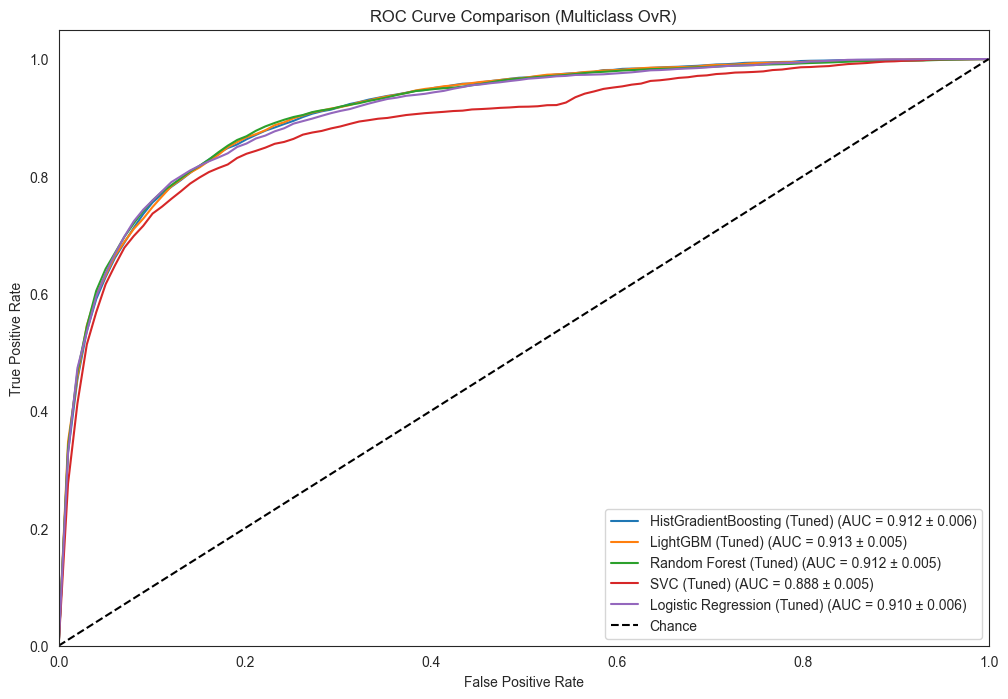

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 8))
cv = StratifiedKFold(n_splits=5)
n_classes = len(np.unique(y))  # jumlah kelas

for name, model in tuned_models.items():
    mean_fpr = np.linspace(0, 1, 100)
    tprs = []
    aucs = []

    for train_index, test_index in cv.split(X, y):
        X_train_cv, X_test_cv = X.iloc[train_index], X.iloc[test_index]
        y_train_cv, y_test_cv = y.iloc[train_index], y.iloc[test_index]

        # Fit model
        model.fit(X_train_cv, y_train_cv)

        # Binarize label (OvR)
        y_test_bin = label_binarize(y_test_cv, classes=np.unique(y))
        
        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_test_cv)
        else:
            y_score = model.decision_function(X_test_cv)

        # Compute macro-average ROC
        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
        roc_auc = auc(fpr, tpr)

        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        aucs.append(roc_auc)

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)
    std_auc = np.std(aucs)

    plt.plot(mean_fpr, mean_tpr,
             label=f"{name} (AUC = {mean_auc:.3f} ± {std_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Chance")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (Multiclass OvR)")
plt.legend(loc="lower right")
plt.show()


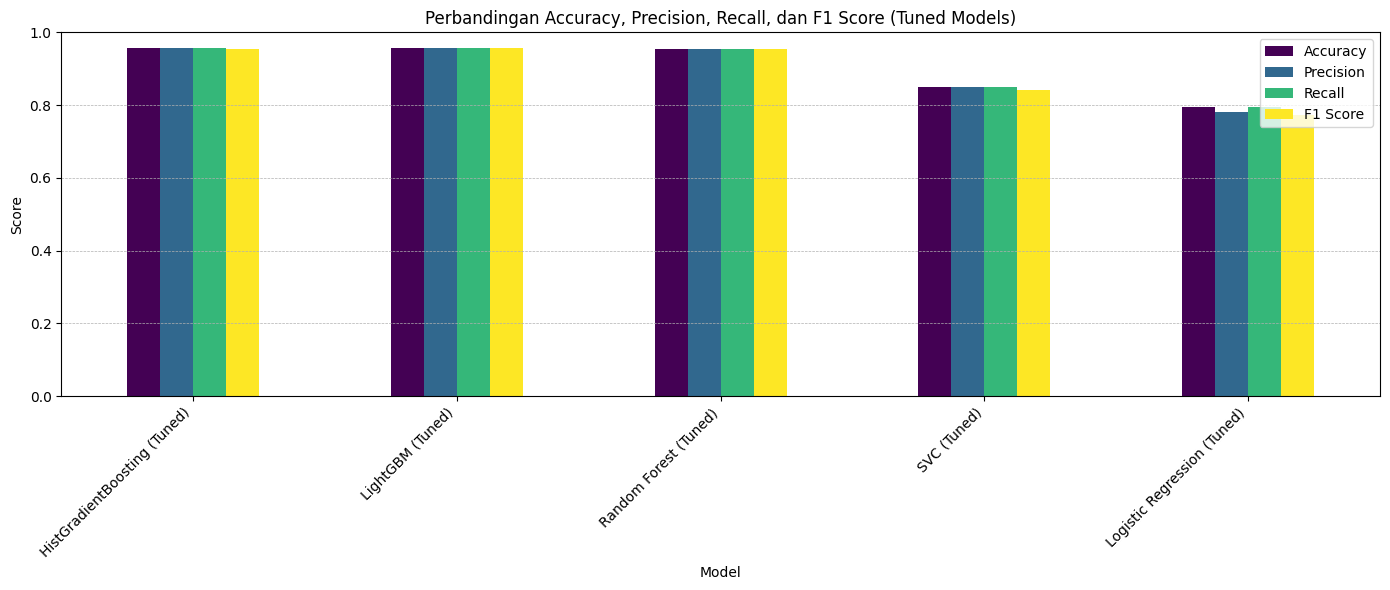

In [89]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd

# Inisialisasi list untuk confusion matrix dan dictionary untuk metrik
all_cms = []
tuned_metrics = {
    "Model": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1 Score": []
}

# Evaluasi semua model yang sudah di-tune
for name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    all_cms.append(cm)

    tuned_metrics["Model"].append(name)
    tuned_metrics["Accuracy"].append(accuracy_score(y_test, y_pred))
    tuned_metrics["Precision"].append(precision_score(y_test, y_pred, average='weighted', zero_division=0))
    tuned_metrics["Recall"].append(recall_score(y_test, y_pred, average='weighted'))
    tuned_metrics["F1 Score"].append(f1_score(y_test, y_pred, average='weighted'))

# Buat dataframe dari tuned_metrics
df_tuned_metrics = pd.DataFrame(tuned_metrics)

# Lanjut ke visualisasi
df_metrics = df_tuned_metrics.set_index("Model")

# Plot bar chart
ax = df_metrics.plot(kind='bar', figsize=(14, 6), colormap='viridis')
ax.set_ylabel('Score')
ax.set_title('Perbandingan Accuracy, Precision, Recall, dan F1 Score (Tuned Models)')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

C:\Users\Mumtaz\AppData\Local\Temp\ipykernel_29252\161404136.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


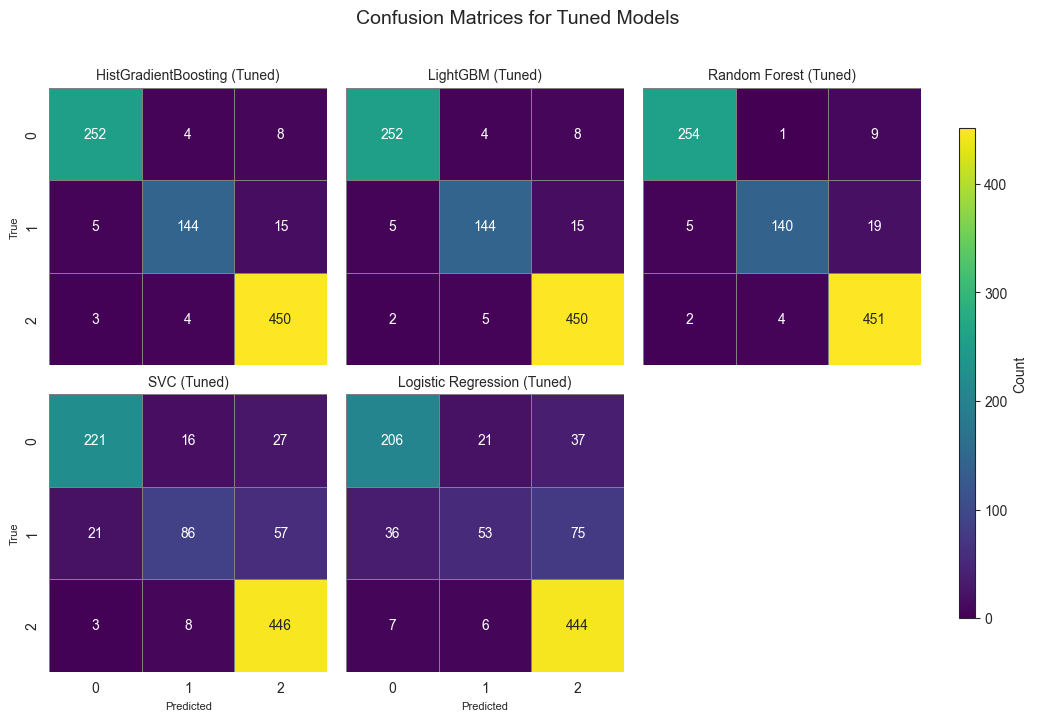

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Gunakan tuned_models, bukan models
n_models = len(tuned_models)
cols = 3
rows = int(np.ceil(n_models / cols))
vmax = max(cm.max() for cm in all_cms)

sns.set_style("white")
fig, axes = plt.subplots(rows, cols,
                         figsize=(cols * 3.5, rows * 3.5),
                         sharex=True, sharey=True)
axes = axes.flatten()

for idx, ((name, model), cm) in enumerate(zip(tuned_models.items(), all_cms)):
    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cbar=False, vmin=0, vmax=vmax, square=True,
                linewidths=0.5, linecolor='gray', cmap="viridis")
    ax.set_title(name, fontsize=10)

    row = idx // cols
    col = idx % cols

    ax.set_xlabel("Predicted" if row == rows - 1 else "", fontsize=8)
    ax.set_ylabel("True" if col == 0 else "", fontsize=8)

# Hapus axes kosong jika ada
for j in range(n_models, len(axes)):
    fig.delaxes(axes[j])

# Tambahkan colorbar global
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
norm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin=0, vmax=vmax))
norm.set_array([])
fig.colorbar(norm, cax=cbar_ax, label="Count")

plt.suptitle("Confusion Matrices for Tuned Models", fontsize=14, y=1.02)
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()
